In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud
from scipy.cluster.hierarchy import dendrogram, linkage
from pandas.plotting import parallel_coordinates, andrews_curves

df = pd.read_csv("2019.csv")

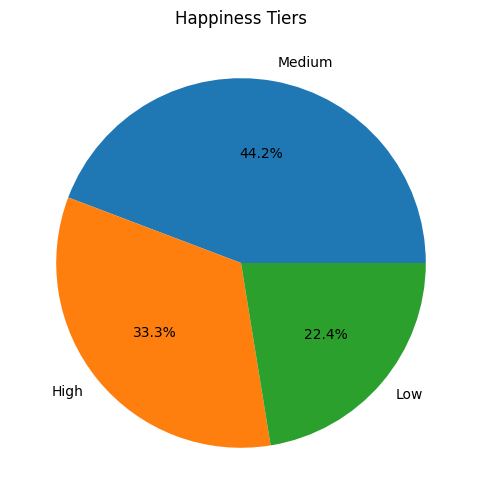

In [14]:
#Pie Chart: plot_pie(data, labels, title="Pie Chart")
score_categories = pd.cut(df['Score'], bins=[0, 4.5, 6, 8], labels=['Low', 'Medium', 'High'])
pie_data = score_categories.value_counts()
plt.figure(figsize=(6, 6))
plt.pie(pie_data, labels=pie_data.index, autopct='%1.1f%%')
plt.title("Happiness Tiers")
plt.show()

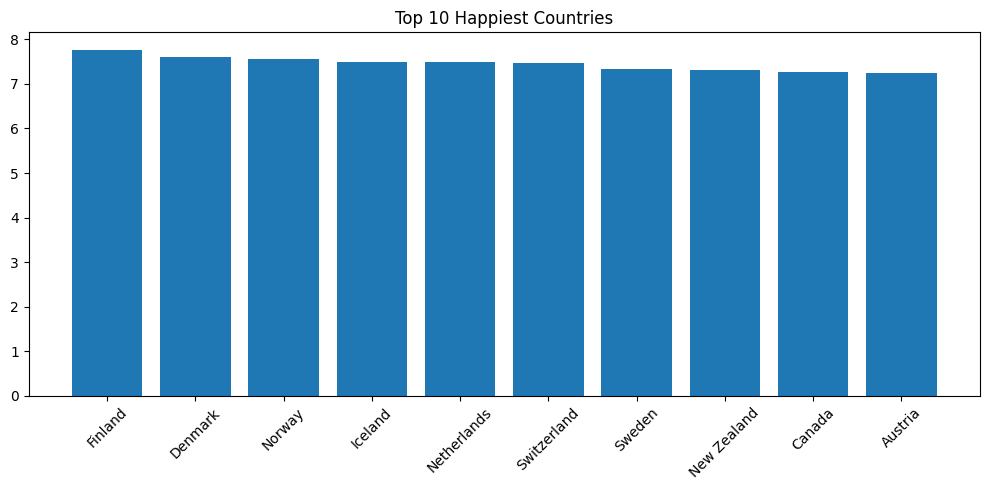

In [15]:
#Bar Chart: plot_bar(categories, values, title="Bar Chart")
top_10 = df.head(10)
plt.figure(figsize=(10, 5))
plt.bar(top_10['Country or region'], top_10['Score'])
plt.title("Top 10 Happiest Countries")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

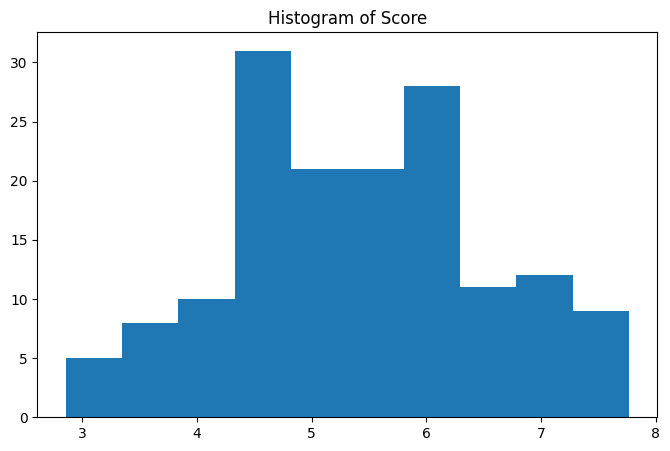

In [16]:
#Histogram: plot_histogram(df, column)
plt.figure(figsize=(8, 5))
plt.hist(df['Score'].dropna())
plt.title("Histogram of Score")
plt.show()

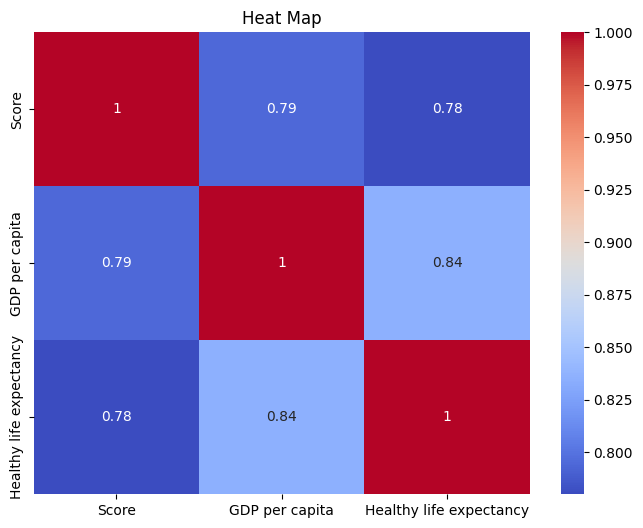

In [17]:
#Heat Map: heatmap(df, annot=True, cmap='coolwarm')
plt.figure(figsize=(8, 6))
sns.heatmap(df[['Score', 'GDP per capita', 'Healthy life expectancy']].corr(), annot=True, cmap='coolwarm')
plt.title("Heat Map")
plt.show()

In [26]:
#Choropleth Map: import plotly.express as px
fig = px.choropleth(df, locations="Country or region", locationmode='country names', color="Score")
fig.show(renderer="colab")

/tmp/ipykernel_1286/2452283708.py:2: FutureWarning:

Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.



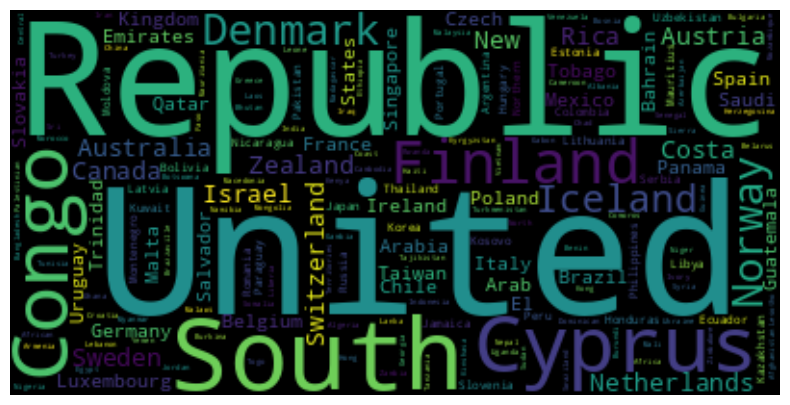

In [19]:
#Word Cloud: from wordcloud import WordCloud
text = " ".join(df['Country or region'].dropna().ravel())
wordcloud = WordCloud().generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

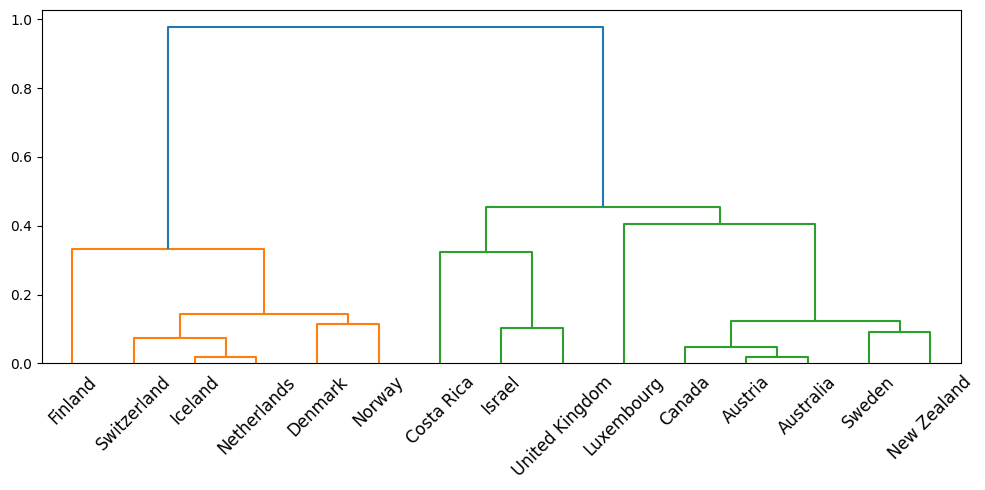

In [20]:
#Dendrograms: from scipy.cluster.hierarchy import dendrogram, linkage
sample = df.head(15)
linked = linkage(sample[['Score', 'GDP per capita']], 'ward')
plt.figure(figsize=(10, 5))
dendrogram(linked, labels=sample['Country or region'].values)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


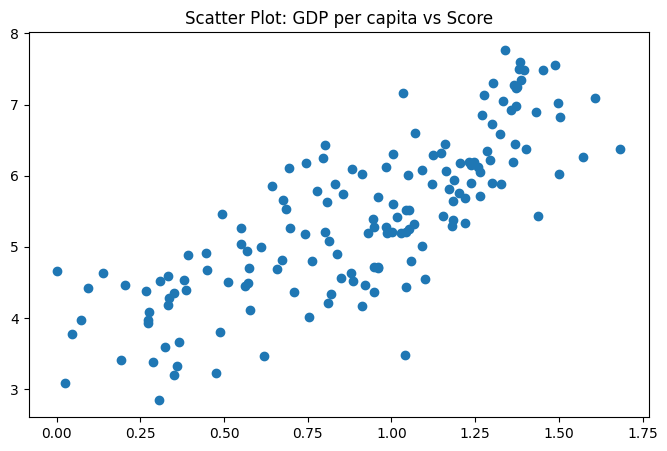

In [21]:
#Scatter plots: scatter(df[x], df[y])
plt.figure(figsize=(8, 5))
plt.scatter(df['GDP per capita'], df['Score'])
plt.title("Scatter Plot: GDP per capita vs Score")
plt.show()

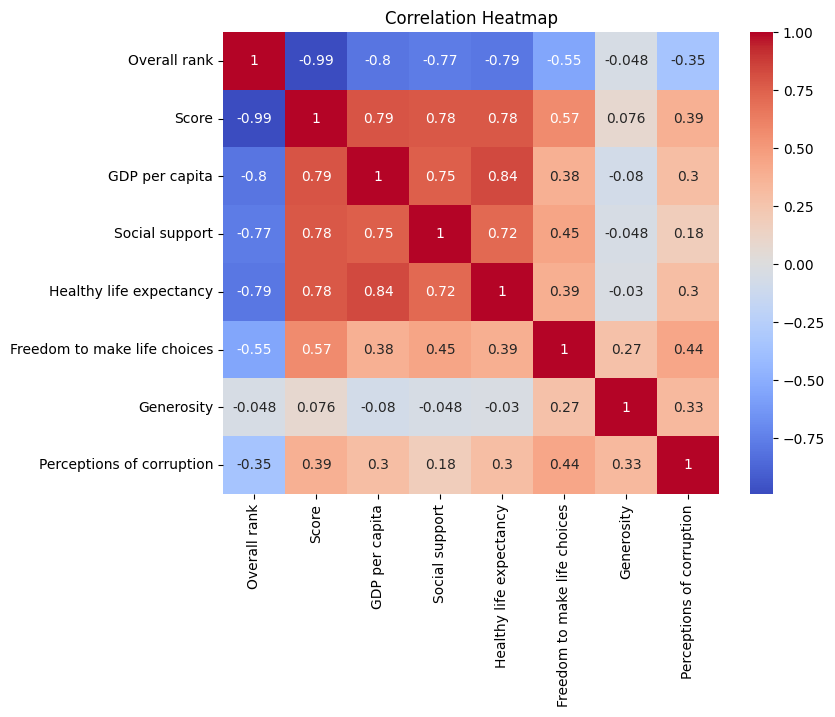

In [22]:
#Correlation Heatmap: sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

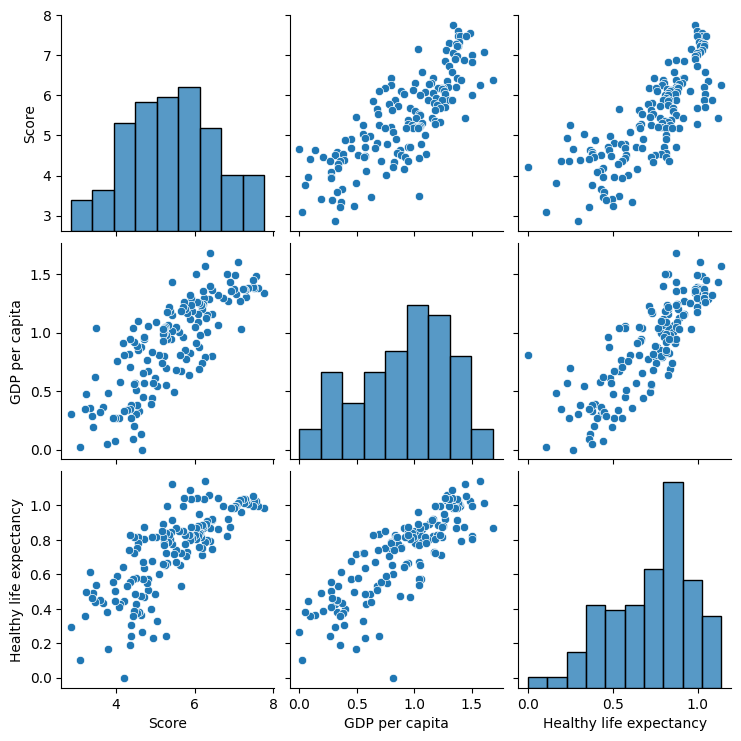

In [23]:
#Pair plots: sns.pairplot(df)
sns.pairplot(df[['Score', 'GDP per capita', 'Healthy life expectancy']])
plt.show()

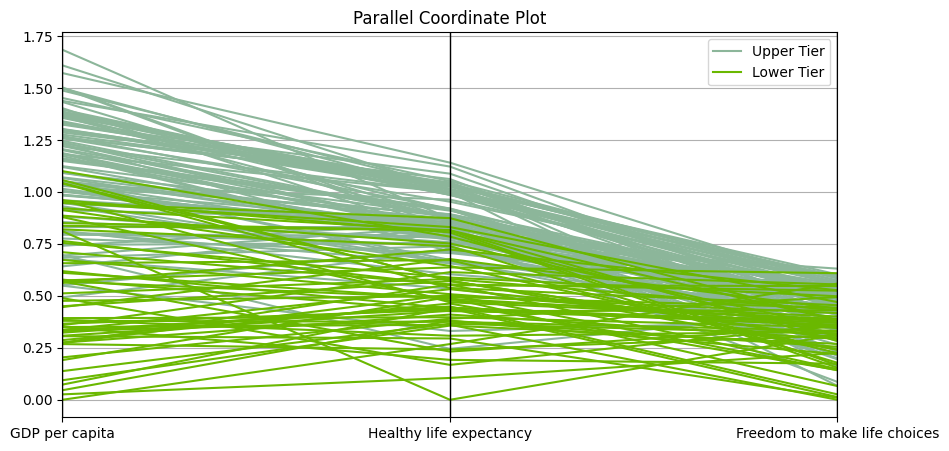

In [24]:
#Parallel Coordinate Plots: from pandas.plotting import parallel_coordinates
df['Tier'] = pd.cut(df['Score'], bins=[0, 5, 8], labels=['Lower Tier', 'Upper Tier'])
plt.figure(figsize=(10, 5))
parallel_coordinates(df[['Tier', 'GDP per capita', 'Healthy life expectancy', 'Freedom to make life choices']], 'Tier')
plt.title("Parallel Coordinate Plot")
plt.show()

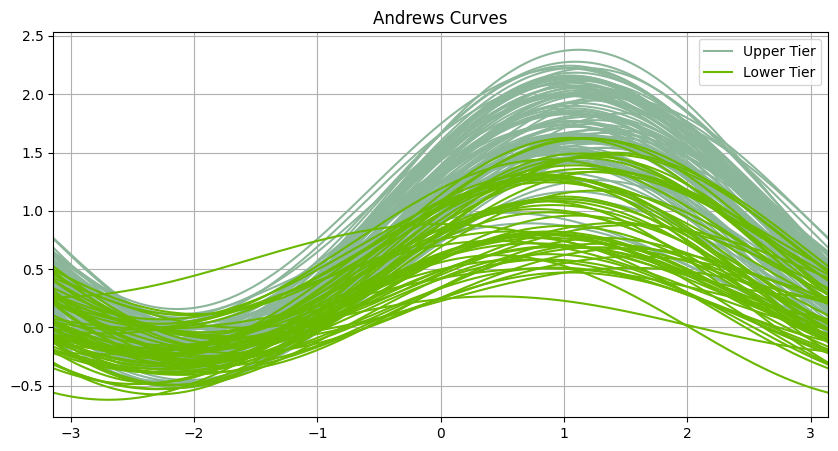

In [25]:
#Andrews Curves: from pandas.plotting import andrews_curves
plt.figure(figsize=(10, 5))
andrews_curves(df[['Tier', 'GDP per capita', 'Healthy life expectancy', 'Freedom to make life choices']], 'Tier')
plt.title("Andrews Curves")
plt.show()